<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/7_forest_roc_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, auc

## STEP 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## STEP 3: Prepare Data

In [3]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

## STEP 4: Binarize Target
ROC needs binary format

In [4]:
classes = sorted(y.unique())

y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

## STEP 5: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

## STEP 6: Train Model

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## STEP 7: Predict Probabilities

In [7]:
y_score = model.predict_proba(X_test)

# Convert list → array (correct way)
y_score = np.stack([y_score[i] for i in range(len(y_score))])

## STEP 8: Compute ROC Curve

In [8]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[i, :, 1])
    roc_auc[i] = auc(fpr[i], tpr[i])

## STEP 9: Plot ROC Curve

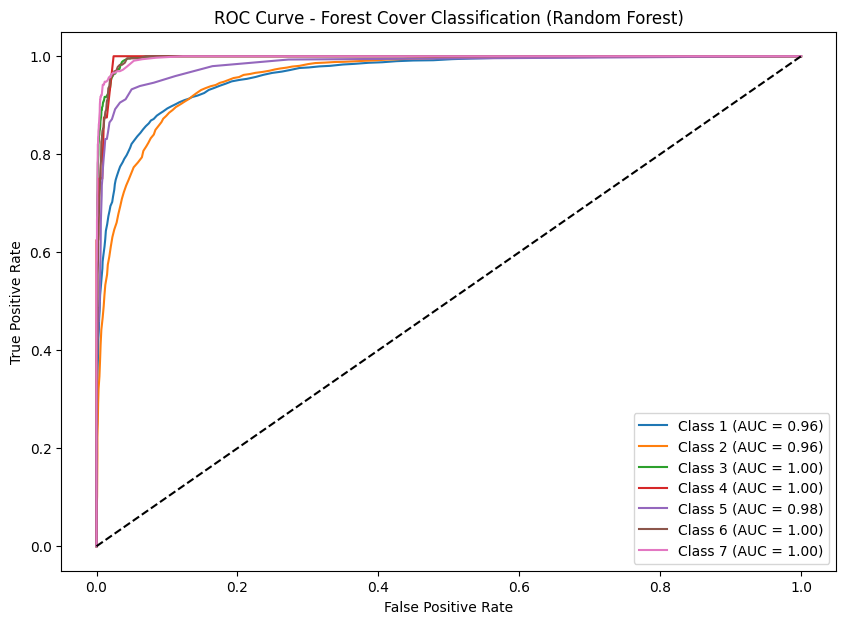

In [9]:
plt.figure(figsize=(10,7))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Forest Cover Classification (Random Forest)")
plt.legend(loc="lower right")

plt.show()

## STEP 10: Macro-Average ROC

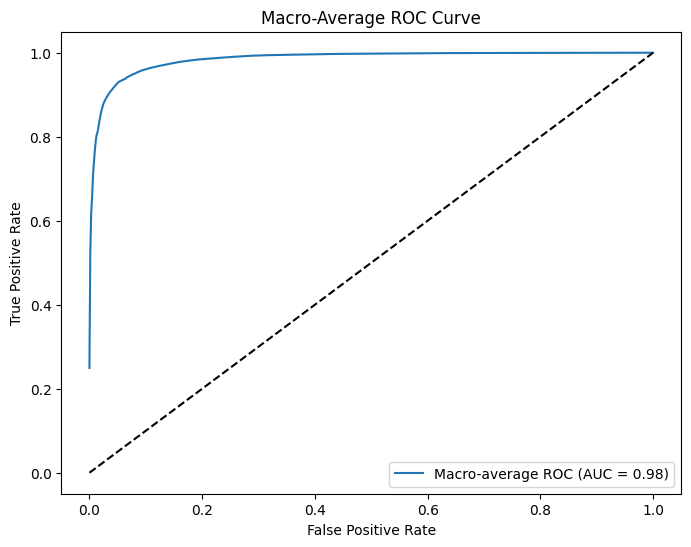

In [10]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend()
plt.show()

## FINAL INSIGHTS
1. The model demonstrates strong classification performance, with most classes showing high AUC values, indicating good separability.

2. The ROC curves are well above the diagonal baseline, confirming that the model performs significantly better than random guessing.

3. Some classes show slightly lower AUC, suggesting that those forest cover types have overlapping feature characteristics and are harder to distinguish.

4. The macro-average ROC curve indicates that overall model performance is consistent and reliable across all classes.

5. The results confirm that the Random Forest model is robust for multi-class forest classification tasks.